In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime

from src import ASCAT_ERA5_data_cleaning as utils
from src.general_data_cleaning_utils import plot

# Data Understanding and Preparation of the ASCAT and ERA5 Data

The goal is to generate descriptive statistics, drop missing values & outliers, and plot the data for all ASCAT and ERA5 data in `data/raw/ASCAT` and `data/raw/ERA`. The cleaned data will then be exported to their respective folders in `data/cleaned`.

---

### Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **ISMN Stations**
    - *2.1 Aberdeen-35-WNW*
    - *2.2 Jamestown-38-WSW*
    - *2.3 Gobblers Knob*
    - *2.4 Nenana*
    - *3.5 L23*
    - *3.6 L38*
    - *3.7 NST-07*
    - *3.8 NST-09*
    - *3.9 SOD012*
    - *3.10 SOD103*

---

## 1. Setup

### 1.1 Variables

In [2]:
# key columns
backscatter = 'backscatter40'
ERA5_5cm_soil_temp = 'stl1'

# path variables
ASCAT = 'ASCAT'
ERA5 = 'ERA5'
raw_path = Path('../data/raw')
cleaned_path = Path('../data/cleaned')
Path(cleaned_path / ASCAT).mkdir(parents=True, exist_ok=True)
Path(cleaned_path / ERA5).mkdir(parents=True, exist_ok=True)

# station names
aberdeen_name = 'Aberdeen-35-WNW'
jamestown_name = 'Jamestown-38-WSW'
gobblers_knob_name = 'GobblersKnob'
nenana_name = 'Nenana'
L23_name = 'L23'
L38_name = 'L38'
NST_07_name = 'NST-07'
NST_09_name = 'NST-09'
SOD012_name = 'SOD012'
SOD103_name = 'SOD103'

### 1.2 Functions

In [3]:
def data_cleaning(path: Path, station: str, system: str, key_variable: str) -> pd.DataFrame:
    """
    Preprocessing of raw ASCAT or ERA5 data.
    :param path: path to csv file
    :param station: must match part in filename, case-insensitive
    :param system: ASCAT or ERA5, case-insensitive
    :param key_variable: name of variable of interest (in csv)
    :return:
    """
    # check input values
    if not path.is_dir():
        raise ValueError(f'path ({path}) must point to a directory')
    if system.upper() not in ['ASCAT', 'ERA5']:
        raise ValueError(f'{system} must be ASCAT or ERA5 (case-insensitive)')

    df = utils.collect_data(Path(raw_path / system), station, system)
    utils.check_df_cols(df, system)
    df = df.dropna(subset=[key_variable]) # interpolation not recommended
    df = utils.round_nearest_hour(df)

    return df

## 2. ISMN Stations

### 2.1 Aberdeen-35-WNW

#### ASCAT

In [4]:
ASCAT_Aberdeen_df = data_cleaning(raw_path / ASCAT, aberdeen_name, ASCAT, backscatter)
ASCAT_Aberdeen_df.head()

,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-01 04:00:00+00:00,-18.138327,1,0,3
2007-01-02 04:00:00+00:00,-18.249712,1,0,3
2007-01-02 16:00:00+00:00,-18.546434,1,1,3
2007-01-03 17:00:00+00:00,-17.615808,0,1,3
2007-01-04 03:00:00+00:00,-15.992000,0,0,3


In [5]:
ASCAT_Aberdeen_df.describe()

,backscatter40,swath_indicator,as_des_pass,sat_id
count,16181.000000,16181.000000,16181.000000,16181.000000
mean,-14.759586,0.497497,0.490328,3.727458
std,1.715188,0.500009,0.499922,0.751516
min,-19.637800,0.000000,0.000000,3.000000
25%,-15.928318,0.000000,0.000000,3.000000
50%,-14.600672,0.000000,0.000000,4.000000
75%,-13.589661,1.000000,1.000000,4.000000
max,-6.488361,1.000000,1.000000,5.000000


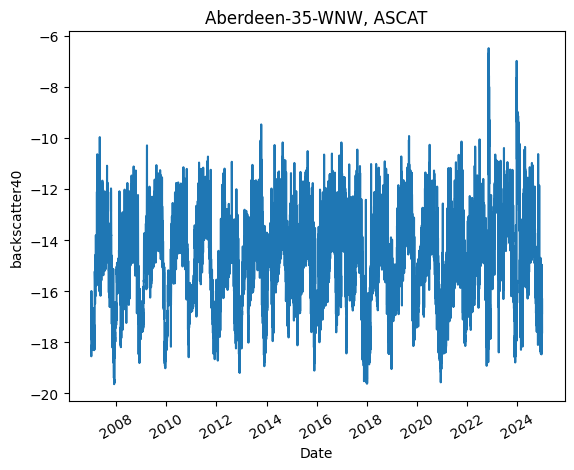

In [6]:
plot(ASCAT_Aberdeen_df, backscatter, aberdeen_name, ASCAT, 'line')

#### ERA5

In [10]:
ERA5_aberdeen_df = data_cleaning(raw_path / ERA5, aberdeen_name, ERA5, ERA5_5cm_soil_temp)
ERA5_aberdeen_df.head()

,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-8.824951,-3.689606,-1.241242,0.236350,0.243425,0.011896
2007-01-01 06:00:00+00:00,-10.743195,-6.642731,-1.306000,0.236399,0.243433,0.011884
2007-01-01 12:00:00+00:00,-12.849762,-8.534576,-1.427521,0.236382,0.243390,0.011883
2007-01-01 18:00:00+00:00,-6.766449,-4.998962,-1.519897,0.236419,0.243401,0.011862
2007-01-02 00:00:00+00:00,-10.536652,-3.941009,-1.538055,0.236313,0.243309,0.011836


In [11]:
ERA5_aberdeen_df.describe()

,skt,stl1,stl2,swvl1,swvl2,sd
count,2.776000e+04,2.776000e+04,2.776000e+04,2.776000e+04,2.776000e+04,2.776000e+04
mean,-2.846808e+07,-2.846807e+07,-2.846807e+07,-2.846808e+07,-2.846808e+07,-2.846808e+07
std,2.456145e+08,2.456145e+08,2.456145e+08,2.456145e+08,2.456145e+08,2.456145e+08
min,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09,-2.147484e+09
25%,-4.151199e+00,-1.496826e+00,-1.096054e+00,2.211299e-01,2.187474e-01,0.000000e+00
50%,6.740875e+00,7.073288e+00,7.228012e+00,2.793277e-01,2.604254e-01,0.000000e+00
75%,1.748071e+01,1.788146e+01,1.821042e+01,3.228526e-01,3.065530e-01,2.416134e-03
max,4.123581e+01,3.354282e+01,2.891586e+01,4.392079e-01,4.370509e-01,1.212902e-01


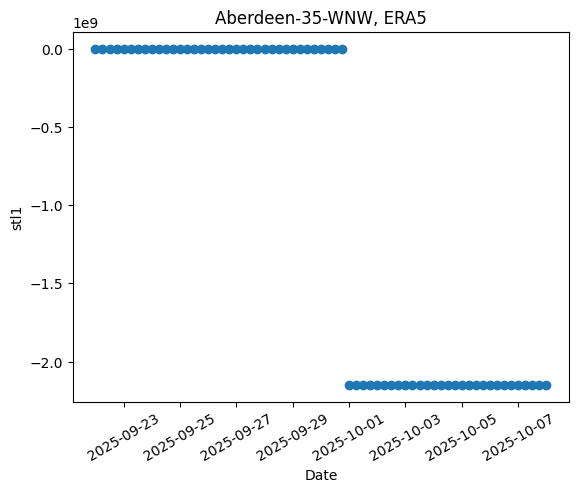

In [17]:
plot(ERA5_aberdeen_df, ERA5_5cm_soil_temp, aberdeen_name, ERA5, 'line')